In [1]:
import pandas as pd
import umap
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch.optim
import torch.nn as nn
import seaborn as sns
from PIL import Image
import numpy as np
from sklearn.neighbors import LocalOutlierFactor

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

/Users/bw/GITS/ITMO/LAB_VAL_1/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
images = pd.read_csv('./V1/d1.csv')
y = images['label']
X = images.drop('label', axis=1)

images_test = pd.read_csv('./V1/mnist_test.csv')
y_test = images_test['label']
X_test = images_test.drop('label', axis=1)

In [3]:
manifold = umap.UMAP(random_state=42).fit(X, y)
X_reduced = manifold.transform(X)
print(X.shape, X_reduced.shape)

/Users/bw/GITS/ITMO/LAB_VAL_1/venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(60000, 784) (60000, 2)


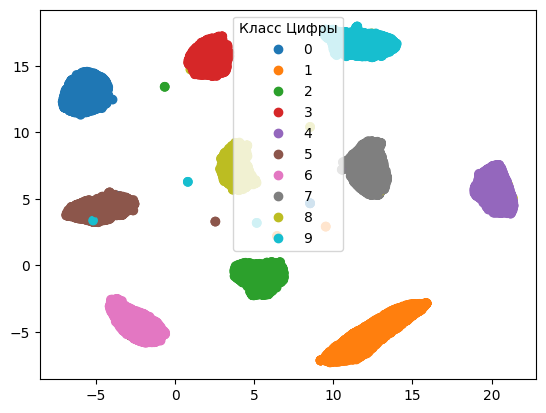

In [4]:
%matplotlib inline
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='tab10')
handels, elemnts = scatter.legend_elements()
plt.legend(handels, elemnts, title='Класс Цифры')
plt.show()

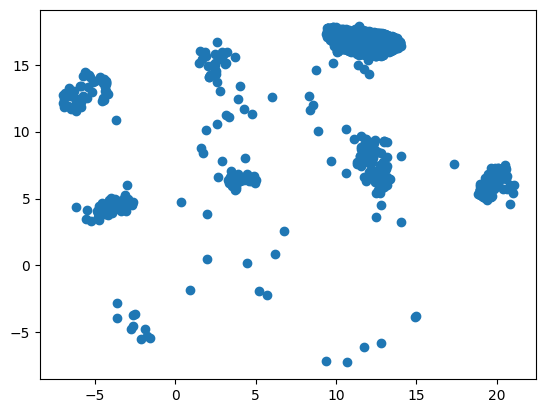

In [5]:
nines = images[images['label'] == 9]
nine_reduced = manifold.transform(nines)
plt.scatter(nine_reduced[:, 0], nine_reduced[:, 1])

In [6]:
lof = LocalOutlierFactor(n_neighbors=15, contamination=0.001)
is_inliner = lof.fit_predict(X_reduced)
X_copy = X.copy()
X_copy['is_anomaly'] = is_inliner
anomalies = X_copy[X_copy['is_anomaly'] == -1]
print(len(anomalies))

60


In [7]:
first_row = X.iloc[1]
def to_image(str_img):
    return Image.fromarray(np.array(str_img,dtype=np.uint8).reshape((28,28)), mode='L')
image1 = to_image(first_row)

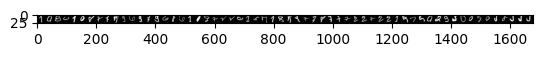

In [8]:
show_anomalies = []
for i in range(len(anomalies)):
    show_anomalies.append(to_image(anomalies.iloc[i].drop('is_anomaly')))

total_width = sum(img.width for img in show_anomalies)
max_height = max(img.height for img in show_anomalies)

horizontal_combo = Image.new("RGB", (total_width, max_height))

x_offset = 0
for img in show_anomalies:
    horizontal_combo.paste(img, (x_offset, 0))
    x_offset += img.width

plt.imshow(horizontal_combo)

In [9]:
# show_anomalies.shape
# plt.plot(show_anomalies[1])

In [10]:
# scatter_anomalies = anomalies.drop('is_anomaly', axis=1)

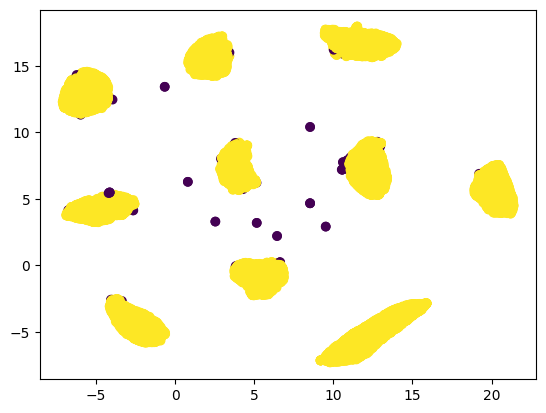

In [11]:
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=X_copy['is_anomaly'])

(60000, 2)


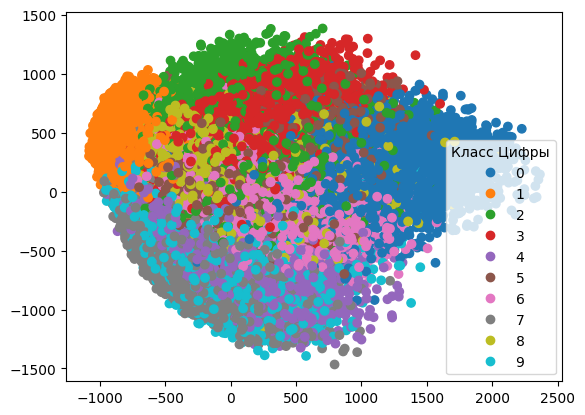

In [12]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X)
print(X_train_pca.shape)
scatter_pca = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y, cmap='tab10')
handels, elemnts = scatter_pca.legend_elements()
plt.legend(handels, elemnts, title='Класс Цифры')
plt.show()

In [13]:
from sklearn.manifold import TSNE
model = TSNE(n_components = 2, random_state = 42)

tsne_data = model.fit_transform(X)


(60000, 2)


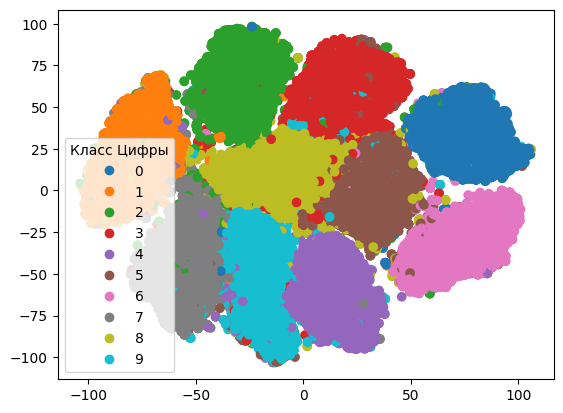

In [14]:
print(tsne_data.shape)
scatter_tsne = plt.scatter(tsne_data[:, 0], tsne_data[:, 1], c=y, cmap='tab10')
handels, elemnts = scatter_tsne.legend_elements()
plt.legend(handels, elemnts, title='Класс Цифры')
plt.show()

(array([5923., 6742., 5958., 6131., 5842., 5421., 5918., 6265., 5851.,
        5949.]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

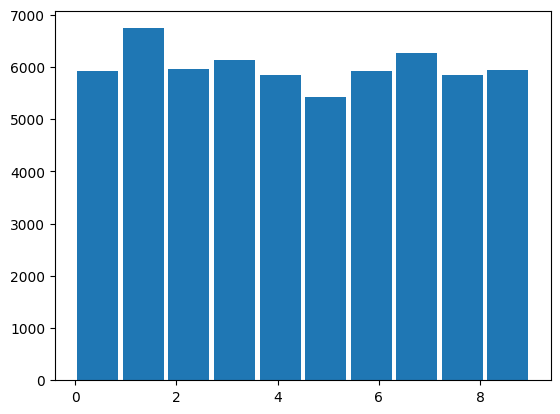

In [15]:
# images['label'].hist()
plt.hist(images['label'], rwidth=0.9)

<Axes: >

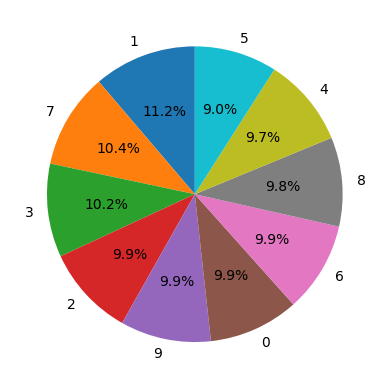

In [16]:
images['label'].value_counts().plot.pie(autopct='%1.1f%%', 
    startangle=90, 
    ylabel='')

In [17]:
counts = images['label'].value_counts()
imbalance_ratio = counts.max() / counts.min()
print('Коэффициент дисбаланса', imbalance_ratio)
print('Индекс Gini:', 1 - (images['label'].value_counts(normalize=True) ** 2).sum())

Коэффициент дисбаланса 1.243681977494927
Индекс Gini: 0.8997118405555555


In [18]:
# sum = np.array(to_image(X.iloc[0]), dtype=float)
# for i in range(1, len(X)):
#     sum += np.array(to_image(X.iloc[i]), dtype=float)

In [19]:
# del sum

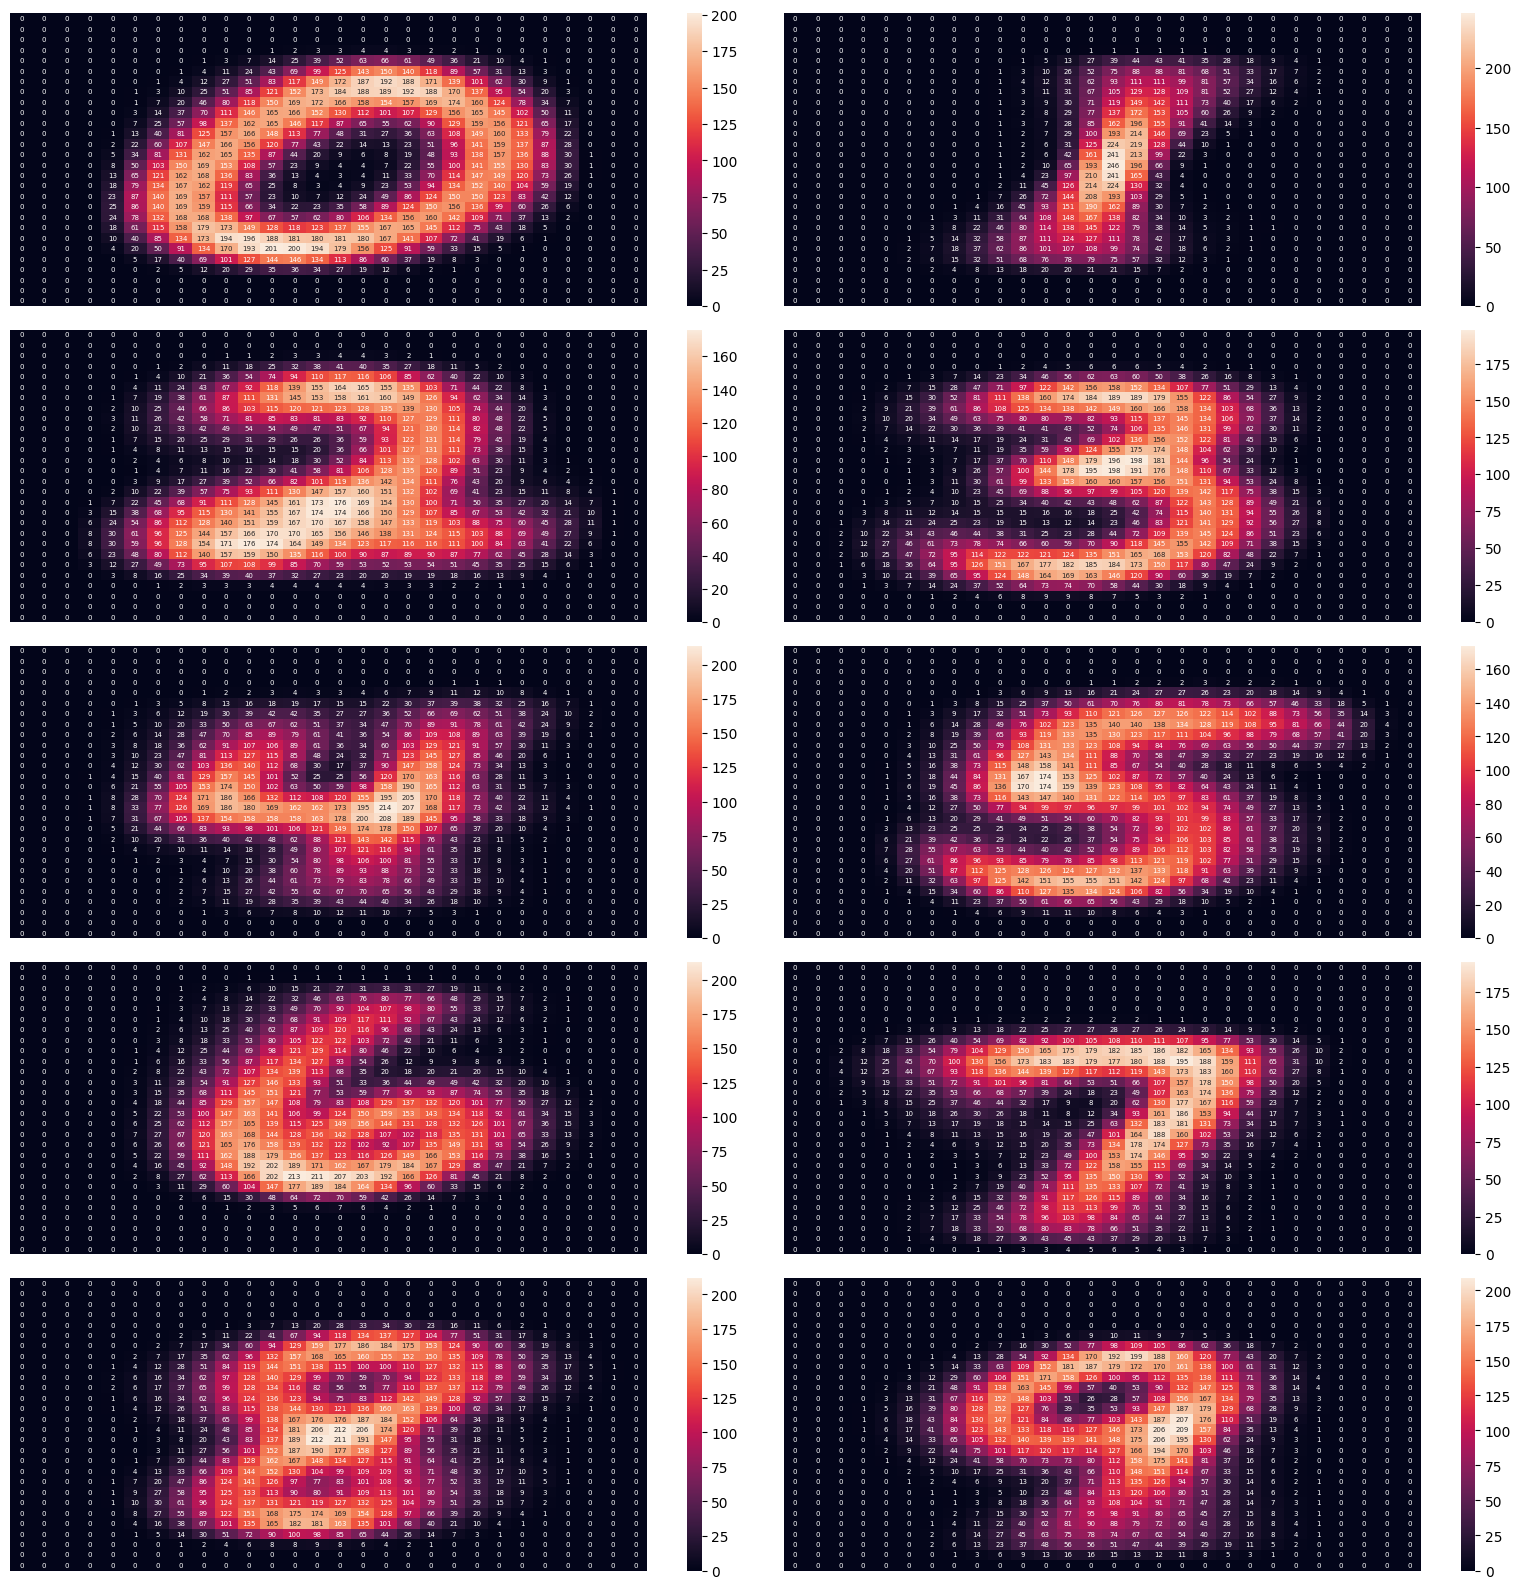

In [20]:
test = images.groupby('label').mean()
mean_img_classes = []
for i in range(len(test)):
    mean_img_classes.append(to_image(test.iloc[i]))


fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 16))
axes = axes.flatten()
for i, matrix in enumerate(mean_img_classes):
    sns.heatmap(matrix, ax=axes[i], annot=True, fmt="d",annot_kws={"size": 5})
    # axes[i].set_title(titles[i], fontsize=16, weight='bold', pad=15) # Заголовок для каждого графика
    axes[i].axis('off')
plt.tight_layout()


In [21]:
# # images['1x1'].mean()



# total_height = sum(img.height for img in mean_img_classes)
# max_width = max(img.width for img in mean_img_classes)

# horizontal_combo = Image.new("RGB", (max_width, total_height))

# y_offset = 0
# for img in mean_img_classes:
#     horizontal_combo.paste(img, (0, y_offset))
#     y_offset += img.height

# plt.imshow(horizontal_combo)

In [22]:
# Image.fromarray((sum/len(X)).astype('uint8'), 'L').resize((256,256))

In [23]:
# test = images.dropna()
# print(images.shape, test.shape)
# test = images.drop_duplicates()
# print(X.shape)
# test = X.drop_duplicates()
duplicates = images.duplicated()
print('Дубликаты изображений с одинаковыми метками: ', duplicates.sum())
duplicates_diff = X.duplicated()
print('Дубликаты изображений с разными метками: ', duplicates_diff.sum())
print('Диапазон значений: ', X.min().min(), X.max().max())


Дубликаты изображений с одинаковыми метками:  0
Дубликаты изображений с разными метками:  0
Диапазон значений:  0 255


In [3]:

class NeuralNetwork(nn.Module):
    def __init__(self, p_val):
        super().__init__()
        self.p_val = p_val
        self.l1 = nn.Linear(28*28, 8)
        self.l2 = nn.Linear(8, 10)

    def forward(self, x):
        x = nn.functional.dropout(nn.functional.relu(self.l1(x)), self.p_val)
        x = self.l2(x)
        return x


In [ ]:
BATCH_SIZE = 128
EPOCHS = 3

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(4, 4))
for p_val in range(0, 10, 2):
    model = NeuralNetwork(p_val * 0.1)
    opt = torch.optim.NAdam(model.parameters(), lr=3e-4)
    loss_func = nn.CrossEntropyLoss()
    losses = []

    test_loss = []
    for j in range(EPOCHS):
        labels = []
        for i in range(0, len(X), BATCH_SIZE):
            outputs = model(torch.Tensor(np.array(X[i:i+BATCH_SIZE], dtype=np.float32)))
            # print(outputs)
            labels += torch.argmax(outputs.detach(), dim=1)
            loss = loss_func(outputs, torch.tensor(np.array(y[i:i+BATCH_SIZE]), dtype=torch.long))
            loss.backward()
            opt.step()
            model.zero_grad()
            losses.append(loss.item())
        save_loss_test = []
        for i in range(0, len(X_test)):
            outputs = model(torch.Tensor(np.array(X_test[i:i+BATCH_SIZE], dtype=np.float32)))
            # print(outputs)
            labels += torch.argmax(outputs.detach(), dim=1)
            loss = loss_func(outputs, torch.tensor(np.array(y_test[i:i+BATCH_SIZE]), dtype=torch.long))
            save_loss_test.append(loss.item())
        test_loss.append(torch.tensor(save_loss_test).mean())


            
    axes[0].plot(losses, label=f'{p_val * 0.1}')
    axes[1].plot(test_loss, label=f'{p_val * 0.1}')
plt.legend()
plt.yscale('log')
# plt.loglog()
plt.ylim(0, 3)
plt.show()


In [21]:
# plt.plot(losses)

In [22]:
# for i in range(len(labels)):
#     labels[i] = torch.argmax(labels[i])

In [25]:


# Расчет метрик
# labels = labels 
accuracy = accuracy_score(y, labels)
precision_micro = precision_score(y, labels, average='micro')
precision_macro = precision_score(y, labels, average='macro')
recall_micro = recall_score(y, labels, average='micro')
recall_macro = recall_score(y, labels, average='macro')
f1_macro = f1_score(y, labels, average='macro')
f1_micro = f1_score(y, labels, average='micro')

print('accuracy', accuracy)
print('precision_micro', precision_micro)
print('precision_macro', precision_macro)
print('recall_micro', recall_micro)
print('recall_macro', recall_macro)
print('f1_micro', f1_micro)
print('f1_macro', f1_macro)


/Users/bw/GITS/ITMO/LAB_VAL_1/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


accuracy 0.10043333333333333
precision_micro 0.10043333333333333
precision_macro 0.10298157314725394
recall_micro 0.10043333333333333
recall_macro 0.10098209539751757
f1_micro 0.10043333333333333
f1_macro 0.027639731539086766


Матрица ошибок в виде массива:
[[5737    0    2    0   20   13   63    0   85    3]
 [   0 6505   38   37    5   26    0   20  104    7]
 [  40   43 5538   36   36   15   63   58  125    4]
 [   9   28  193 5467    7  166   13   67  133   48]
 [  19    7   12    9 5445   19   65   19   48  199]
 [  85   17   21  228   49 4654   79    8  225   55]
 [  62    9   12    0   36   68 5678    0   53    0]
 [  17   51   84   31   36    1    0 5920   13  112]
 [  36   72   48   21   12  109   59   12 5407   75]
 [  28   14    2   83  153   33    1   76   64 5495]]


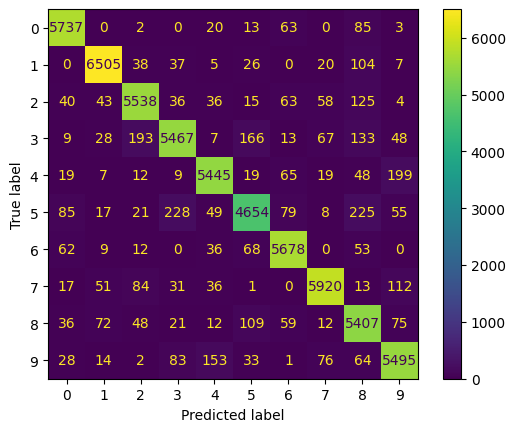

In [ ]:


cm = confusion_matrix(y, labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


<Axes: >

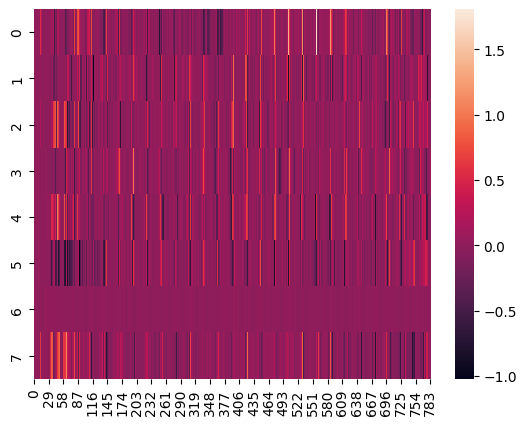

In [497]:
sns.heatmap(model.l1.weight.detach())
# plt.imshow(model.l1.weight.detach(), cmap='magma', aspect='auto')

In [498]:
def vector_to_image_dim(vector_data, size_m):
    # Извлекаем данные для конкретного нейрона (размерность [FLATTEN_DIM])
    neuron_vector = vector_data.mean(dim=0).detach().cpu().numpy()

    # Сначала возвращаем пространственную форму последней свертки: [C, H, W]
    spatial_map = neuron_vector.reshape(1, size_m, size_m)

    # Усредняем по каналам (или берем максимум), чтобы получить 2D-карту активации [H, W]
    heatmap2d = np.mean(spatial_map, axis=0)

    # Нормализуем в диапазон [0, 1] для корректного отображения
    # heatmap2d = (heatmap2d - heatmap2d.min()) / (
    #     heatmap2d.max() - heatmap2d.min() + 1e-8
    # )

    # Апсемплим (интерполируем) до размеров исходного изображения [IMG_H, IMG_W]
    # heatmap_resized = heatmap2d, (IMG_W, IMG_H))
    return heatmap2d


<Axes: >

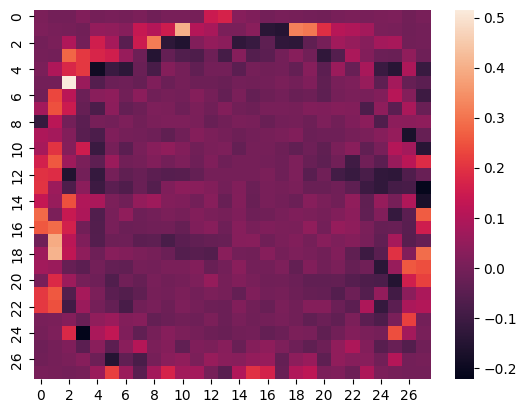

In [499]:
sns.heatmap(vector_to_image_dim(model.l1.weight, 28))

In [500]:
model.l2.weight.shape

torch.Size([10, 8])

In [501]:
X[0:1]

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [502]:
to_image(X[4:5])

<Axes: >

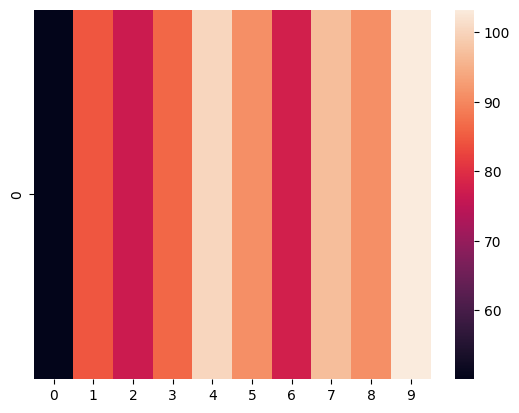

In [503]:
test_img = torch.Tensor(np.array(X[4:5], dtype=np.float32))
# model(test_img)
# vector_to_image_dim(model.l1(test_img), 28)
# model.l1.weight.detach().T) @ model.l2.weight.detach().T
sns.heatmap(nn.functional.relu(test_img @ model.l1.weight.detach().T) @ model.l2.weight.detach().T)#vector_to_image_dim(model.l1.weight, 28)))

In [507]:
sns.heatmap(vector_to_image_dim(model.l2.weight, 2))

ValueError: cannot reshape array of size 8 into shape (1,2,2)